# BTC Spot–Perpetual Basis: Single-Day Causal State-Space Research

This workbench studies one settled UTC day of real Binance `BTCUSDT` spot and USD-M perpetual `aggTrades` data.

## Fixed scope contract

This repository is **intentionally a single-day methodological research project**. Its purpose is to demonstrate causal signal construction, chronological holdout discipline, timestamp-correct proxy economics, reproducibility and falsification on one day.

- Extending this notebook to multiple days is **not a missing task or backlog item for this repository**.
- Multi-day regime stability, rolling refits and cross-date validation belong to a **separate follow-on project**.
- This repository must therefore be judged as a one-day research workbench, not criticised for deliberately excluding a different project.

The notebook does not claim executable P&L. `aggTrades` contains market trade prints, not historical bid/ask depth, queue position or the researcher's counterfactual fills.


## 1. Research map

The day is divided chronologically into four non-overlapping intervals:

1. **Training:** fit the state-space model and the AR(1)/OU baseline.
2. **Threshold development:** run an explicitly exploratory threshold sensitivity sweep.
3. **Purge:** prevent an episode initiated in development from completing in the final holdout.
4. **Final holdout:** evaluate the predeclared signal configuration and causal baselines once.

The one-sided state-space filter continues through all intervals because an online filter naturally carries its state forward. Model parameters are never refitted after the training cutoff.


In [1]:
from __future__ import annotations

import platform
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from research_backtest import (
    ProxyBacktestConfig,
    ProxyBacktestResult,
    run_proxy_backtest_detailed,
    summarize_proxy_result,
)
from research_baselines import (
    ar1_ou_signal_z,
    causal_rolling_z,
    fit_ar1_ou_baseline,
)
from research_data import (
    fetch_archive,
    git_revision,
    infer_timestamp_unit,
    installed_versions,
    to_availability_bars,
    write_research_manifest,
)
from research_validation import (
    benjamini_hochberg,
    circular_block_bootstrap_mean_ci,
    circular_block_bootstrap_mean_test,
    make_intraday_research_split,
)
from state_space import filter_state_space, fit_state_space

plt.rcParams.update({
    "figure.figsize": (12, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)


## 2. Configuration

All primary choices are declared before the data is analysed. The final-holdout strategy uses `ENTRY_Z=2.0`; the development sweep does not select a replacement threshold.

The purge duration covers the maximum holding time plus the full entry- and exit-fill latency budgets. Fee and slippage values are explicit **scenario assumptions**, not claims about the user's exchange tier or achievable execution.

In [2]:
SYMBOL = "BTCUSDT"
DATE = "2026-07-20"
BAR_SECONDS = 1
CACHE_DIR = Path("./data")
OUTPUT_DIR = Path("./artifacts")
PARSER_VERSION = 2

MAX_STALE_SECONDS = 2.0
TRAIN_DURATION = "60000s"
DEVELOPMENT_DURATION = "8000s"
MINIMUM_HOLDOUT_DURATION = "4h"

ENTRY_Z = 2.0
EXIT_Z = 0.25
STOP_Z = 4.0
MAX_HOLD_SECONDS = 60.0
COOLDOWN_SECONDS = 5.0
EXECUTION_DELAY_SECONDS = 1.0
MAX_FILL_DELAY_SECONDS = 2.0

ASSUMED_FEE_BP_PER_FILL = 2.0
ASSUMED_SLIPPAGE_BP_PER_FILL = 0.10
ALLOW_SHORT_SPOT = False
RUN_DIAGNOSTIC_BACKTEST = True

MIN_DELTA_BIC = 10.0
MAX_IDENTIFICATION_RATIO = 2.0
MIN_FINAL_TRADES_FOR_INFERENCE = 20

ROLLING_WINDOW_SECONDS = 300
ROLLING_MIN_PERIODS = 120
# Keep STOP_Z fixed so this is an entry-threshold sweep, not a joint threshold/stop sweep.
THRESHOLD_GRID = np.arange(0.75, STOP_Z, 0.25)
BOOTSTRAP_REPLICATIONS = 2_000

PURGE_SECONDS = (
    MAX_HOLD_SECONDS
    + 2.0 * (EXECUTION_DELAY_SECONDS + MAX_FILL_DELAY_SECONDS)
)
ROUND_TRIP_COST_BP = 4.0 * (
    ASSUMED_FEE_BP_PER_FILL + ASSUMED_SLIPPAGE_BP_PER_FILL
)
COST_STRESS_BP = sorted({0.0, ROUND_TRIP_COST_BP, 20.0, 40.0})

PERP_URL = "https://data.binance.vision/data/futures/um/daily/aggTrades"
SPOT_URL = "https://data.binance.vision/data/spot/daily/aggTrades"

## 3. Checksummed data acquisition

Raw ZIP archives are retained under `data/raw/` and SHA-256 checksummed. Parsed caches include the archive digest in their filename, so a changed archive cannot silently reuse a stale parsed object.

The full regular one-second clock is preserved. A stale or missing observation becomes `NaN`; rows are not deleted because row deletion would compress elapsed time and corrupt both the state equation and holding-period logic.

Bars are labelled at the **right edge**, when every trade included in the bar is observable. Event age is measured from the actual sub-second timestamp of the last trade.


In [3]:
PERP_COLUMNS = [
    "agg_trade_id", "price", "quantity", "first_trade_id",
    "last_trade_id", "transact_time", "is_buyer_maker",
]
SPOT_COLUMNS = PERP_COLUMNS + ["is_best_match"]


def download_agg_trades(
    symbol: str,
    date: str,
    venue: str,
) -> tuple[pd.DataFrame, dict[str, object]]:
    if venue not in {"spot", "perp"}:
        raise ValueError("venue must be 'spot' or 'perp'")

    base = PERP_URL if venue == "perp" else SPOT_URL
    url = f"{base}/{symbol}/{symbol}-aggTrades-{date}.zip"
    raw_path = CACHE_DIR / "raw" / f"{symbol}_{date}_{venue}_aggtrades.zip"
    archive = fetch_archive(url, raw_path, timeout=120.0)

    parsed_path = (
        CACHE_DIR
        / "parsed"
        / f"{symbol}_{date}_{venue}_v{PARSER_VERSION}_{archive.sha256[:12]}.pkl"
    )
    if parsed_path.exists():
        frame = pd.read_pickle(parsed_path)
        required = {"price", "quantity", "transact_time", "timestamp"}
        if not required.issubset(frame.columns):
            raise ValueError("parsed cache does not satisfy the current parser schema")
        member = "cached-parsed-frame"
    else:
        names = PERP_COLUMNS if venue == "perp" else SPOT_COLUMNS
        with zipfile.ZipFile(raw_path) as zipped:
            members = [name for name in zipped.namelist() if name.lower().endswith(".csv")]
            if len(members) != 1:
                raise ValueError(f"expected exactly one CSV archive member, found {members}")
            member = members[0]
            with zipped.open(member) as handle:
                preview = handle.read(300).decode("utf-8", errors="ignore")
                handle.seek(0)
                has_header = "agg_trade_id" in preview or "transact_time" in preview
                frame = pd.read_csv(
                    handle,
                    header=0 if has_header else None,
                    names=None if has_header else names,
                    low_memory=False,
                )

        if "transact_time" not in frame.columns:
            frame.columns = names[: len(frame.columns)]
        for column in ("price", "quantity", "transact_time"):
            frame[column] = pd.to_numeric(frame[column], errors="coerce")
        frame = frame.loc[
            frame[["price", "quantity", "transact_time"]].notna().all(axis=1)
            & (frame["price"] > 0.0)
            & (frame["quantity"] > 0.0)
        ].copy()
        unit = infer_timestamp_unit(frame["transact_time"])
        frame["timestamp"] = pd.to_datetime(
            frame["transact_time"], unit=unit, utc=True
        )
        frame = frame.sort_values("timestamp").reset_index(drop=True)
        parsed_path.parent.mkdir(parents=True, exist_ok=True)
        frame.to_pickle(parsed_path)

    unit = infer_timestamp_unit(frame["transact_time"])
    metadata = archive.to_dict() | {
        "venue": venue,
        "archive_member": member,
        "parser_version": PARSER_VERSION,
        "parsed_cache": str(parsed_path),
        "rows": int(len(frame)),
        "timestamp_unit": unit,
        "first_timestamp": frame["timestamp"].min(),
        "last_timestamp": frame["timestamp"].max(),
    }
    return frame, metadata


perp_trades, perp_archive = download_agg_trades(SYMBOL, DATE, "perp")
spot_trades, spot_archive = download_agg_trades(SYMBOL, DATE, "spot")
perp = to_availability_bars(perp_trades, DATE, BAR_SECONDS).add_prefix("perp_")
spot = to_availability_bars(spot_trades, DATE, BAR_SECONDS).add_prefix("spot_")

panel = perp.join(spot, how="inner")
panel["cross_venue_event_skew_s"] = (
    panel["perp_last_event_time"] - panel["spot_last_event_time"]
).abs().dt.total_seconds()
panel["valid"] = (
    panel["perp_last"].notna()
    & panel["spot_last"].notna()
    & (panel["perp_last"] > 0.0)
    & (panel["spot_last"] > 0.0)
    & (panel["perp_age_s"] <= MAX_STALE_SECONDS)
    & (panel["spot_age_s"] <= MAX_STALE_SECONDS)
)
panel["basis_log"] = np.where(
    panel["valid"],
    np.log(panel["perp_last"]) - np.log(panel["spot_last"]),
    np.nan,
)
panel["basis_bp"] = panel["basis_log"] * 1e4
valid_panel = panel.loc[panel["valid"]]

quality = pd.DataFrame({
    "value": {
        "perpetual aggTrades": len(perp_trades),
        "spot aggTrades": len(spot_trades),
        "all one-second availability timestamps": len(panel),
        "valid aligned timestamps": int(panel["valid"].sum()),
        "valid share": panel["valid"].mean(),
        "basis mean (bp)": valid_panel["basis_bp"].mean(),
        "basis std (bp)": valid_panel["basis_bp"].std(),
        "basis min (bp)": valid_panel["basis_bp"].min(),
        "basis max (bp)": valid_panel["basis_bp"].max(),
        "max perp age retained (s)": valid_panel["perp_age_s"].max(),
        "max spot age retained (s)": valid_panel["spot_age_s"].max(),
        "median cross-venue event skew (s)": valid_panel["cross_venue_event_skew_s"].median(),
        "max cross-venue event skew (s)": valid_panel["cross_venue_event_skew_s"].max(),
    }
})
display(quality)


,value
perpetual aggTrades,1.471068e+06
spot aggTrades,9.414820e+05
all one-second availability timestamps,8.640000e+04
valid aligned timestamps,8.400100e+04
valid share,9.722338e-01
basis mean (bp),-4.232660e+00
basis std (bp),6.877279e-01
basis min (bp),-8.519863e+00
basis max (bp),6.316786e+00
max perp age retained (s),2.000000e+00


## 4. Data-quality inspection

The price and basis plots are diagnostic, not trading evidence. The trade-age panel verifies how often a forward-filled last trade approaches the declared staleness boundary.


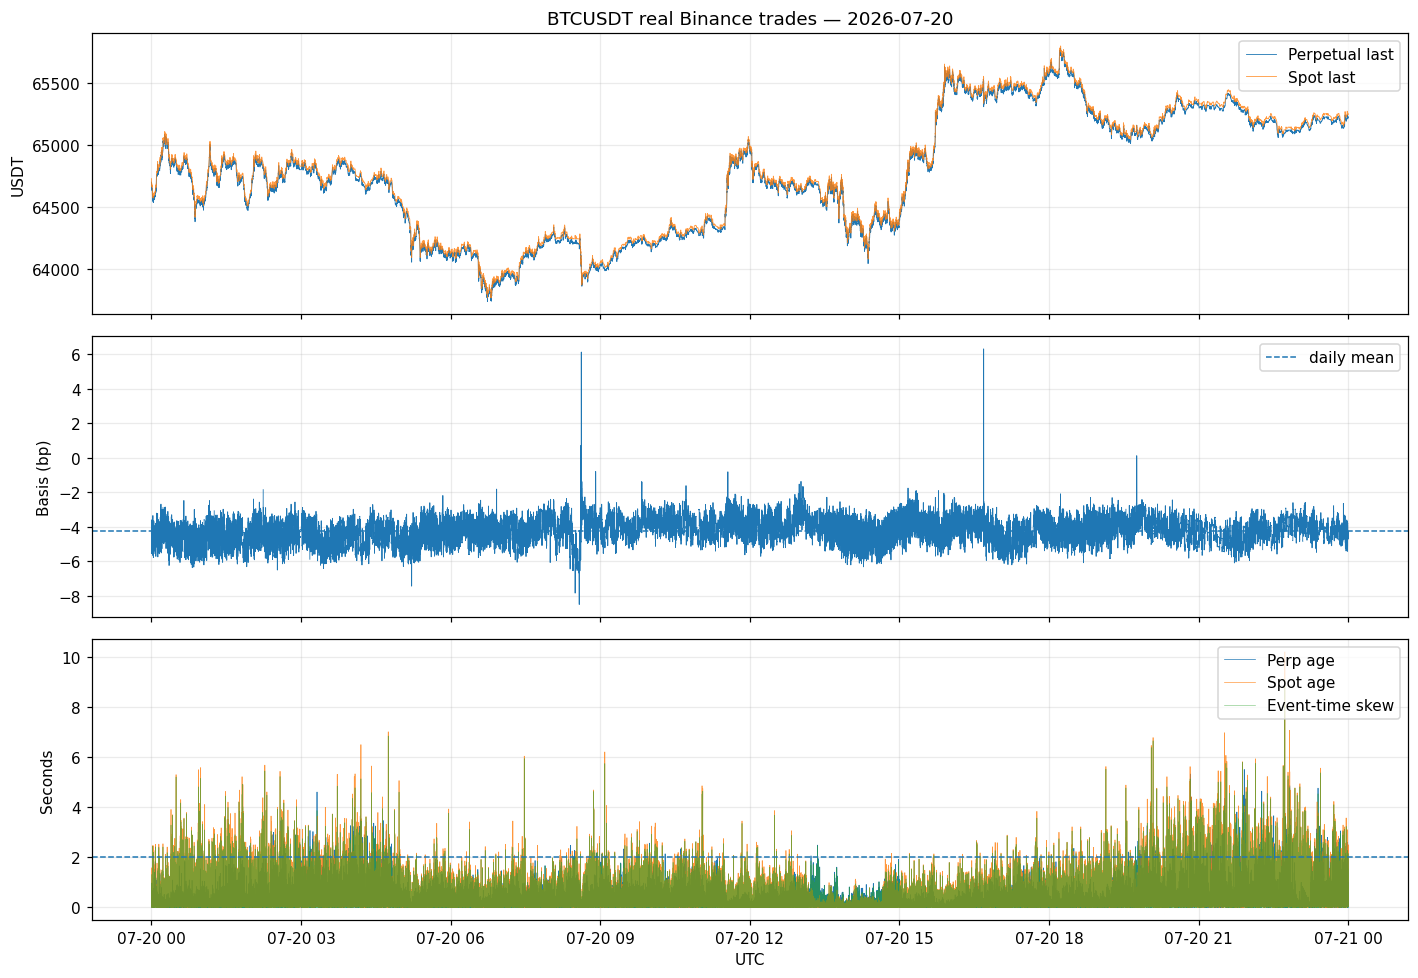

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
axes[0].plot(panel.index, panel["perp_last"], lw=0.55, label="Perpetual last")
axes[0].plot(panel.index, panel["spot_last"], lw=0.55, alpha=0.8, label="Spot last")
axes[0].set_ylabel("USDT")
axes[0].set_title(f"{SYMBOL} real Binance trades — {DATE}")
axes[0].legend(loc="upper right")

axes[1].plot(panel.index, panel["basis_bp"], lw=0.55)
axes[1].axhline(valid_panel["basis_bp"].mean(), ls="--", lw=1, label="daily mean")
axes[1].set_ylabel("Basis (bp)")
axes[1].legend(loc="upper right")

axes[2].plot(panel.index, panel["perp_age_s"], lw=0.45, label="Perp age")
axes[2].plot(panel.index, panel["spot_age_s"], lw=0.45, alpha=0.8, label="Spot age")
axes[2].plot(panel.index, panel["cross_venue_event_skew_s"], lw=0.4, alpha=0.6, label="Event-time skew")
axes[2].axhline(MAX_STALE_SECONDS, ls="--", lw=1)
axes[2].set_ylabel("Seconds")
axes[2].set_xlabel("UTC")
axes[2].legend(loc="upper right")
plt.tight_layout()
plt.show()


## 5. One-day chronological partitions

The threshold-development interval is isolated from the final holdout. The purge is at least the worst-case decision-to-exit-fill duration: maximum holding time plus both successful fill-delay budgets. Therefore a development-period decision cannot produce a realised exit in the holdout.

In [5]:
split = make_intraday_research_split(
    panel.index,
    train_duration=TRAIN_DURATION,
    development_duration=DEVELOPMENT_DURATION,
    purge_duration=pd.Timedelta(seconds=PURGE_SECONDS),
    minimum_holdout_duration=MINIMUM_HOLDOUT_DURATION,
)
display(split.summary())

panel["sample"] = ""
panel.iloc[split.train_positions, panel.columns.get_loc("sample")] = "training"
panel.iloc[
    split.development_positions,
    panel.columns.get_loc("sample"),
] = "threshold_development"
panel.iloc[split.purge_positions, panel.columns.get_loc("sample")] = "purge"
panel.iloc[split.holdout_positions, panel.columns.get_loc("sample")] = "final_holdout"


,start,end_exclusive,clock_observations
training,2026-07-20 00:00:01+00:00,2026-07-20 16:40:01+00:00,60000
threshold_development,2026-07-20 16:40:01+00:00,2026-07-20 18:53:21+00:00,8000
purge,2026-07-20 18:53:21+00:00,2026-07-20 18:54:27+00:00,66
final_holdout,2026-07-20 18:54:27+00:00,2026-07-21 00:00:01+00:00,18334


## 6. Fit the state-space model and causal baselines

The state-space model and AR(1)/OU baseline see only the training interval. The rolling-z comparator uses a reference window ending at `t-1`, so the current observation is excluded from its own normalisation.

The AR(1)/OU baseline is intentionally simple. If the training data cannot support a stationary positive-persistence AR(1), the baseline is marked unavailable rather than coerced into a misleading result.


In [6]:
y = panel["basis_log"].to_numpy(dtype=float)
train_y = y[split.train_positions]
if np.isfinite(train_y).sum() < 500:
    raise ValueError("Training interval contains fewer than 500 valid observations")

fit = fit_state_space(
    train_y,
    dt=float(BAR_SECONDS),
    max_obs=None,
    burn_in=50,
    compare_null=True,
    require_convergence=True,
)
filtered = filter_state_space(y, fit)

panel["level_bp"] = filtered.level * 1e4
panel["transient_bp"] = filtered.transient * 1e4
panel["innovation_z"] = filtered.standardized_innovation
panel["signal_state_space_z"] = filtered.transient_stationary_z(fit.params)
panel["signal_filter_t"] = filtered.transient_filter_t
panel["signal_rolling_z"] = causal_rolling_z(
    y,
    window=ROLLING_WINDOW_SECONDS // BAR_SECONDS,
    min_periods=ROLLING_MIN_PERIODS // BAR_SECONDS,
)

ar1_params = None
ar1_error = None
try:
    ar1_params = fit_ar1_ou_baseline(
        train_y,
        dt_seconds=float(BAR_SECONDS),
        min_pairs=500,
    )
    panel["signal_ar1_ou_z"] = ar1_ou_signal_z(y, ar1_params)
except ValueError as exc:
    ar1_error = str(exc)
    panel["signal_ar1_ou_z"] = np.nan

holdout_start_position = int(split.holdout_positions[0])
holdout_stop_position = int(split.holdout_positions[-1]) + 1
holdout_filtered = filtered.slice(holdout_start_position, holdout_stop_position)
adequacy = holdout_filtered.adequacy_report(
    max_lag=30,
    alpha=0.01,
    require_gaussian=False,
)

if not adequacy.dynamic_passed and not RUN_DIAGNOSTIC_BACKTEST:
    raise RuntimeError(
        "Final-holdout dynamic adequacy failed and diagnostic backtesting is disabled"
    )


## 7. Model fit, identifiability and final-holdout adequacy

A better BIC than the local-level null is necessary but not sufficient. Final-holdout innovations are checked for centring, scale and exact-clock residual autocorrelation: missing seconds are not deleted and observations separated by a gap are not treated as adjacent. Gaussianity is reported separately because heavy tails can invalidate Gaussian inference without necessarily invalidating the conditional mean.

In [7]:
print(fit.report(scale=1e4, unit="bp"))
print()
print(adequacy.summary())
display(pd.Series(adequacy.diagnostics, name="value").to_frame())

if ar1_params is not None:
    display(pd.Series({
        "phi": ar1_params.phi,
        "half-life (s)": ar1_params.half_life_seconds,
        "unconditional mean (bp)": ar1_params.unconditional_mean * 1e4,
        "stationary sd (bp)": ar1_params.stationary_sd * 1e4,
        "training pairs": ar1_params.n_pairs,
    }, name="AR(1)/OU baseline").to_frame())
else:
    print(f"AR(1)/OU baseline unavailable: {ar1_error}")


State-space basis decomposition
  source observations       : 60,000
  fitted observations       : 60,000
  effective likelihood obs  : 58,934
  converged                 : True
  optimiser message         : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  b (AR1 persistence)       : 0.81674246
  half-life                 : 3.424 s
  sigma_level               : 0.029669 bp/step
  sigma_transient           : 0.293533 bp/step
  sigma_observation         : 0.140049 bp
  stationary transient sd   : 0.508721 bp
  log-likelihood            : 521,583.095
  AIC / BIC                 : -1,043,158.190 / -1,043,122.253
  BIC improvement vs null   : 3,823.926
  near-optimal solutions    : 3
  near-optimal HL ratio     : 1.000
  near-optimal signal ratio : 1.000

State-space model adequacy
  overall pass       : False
  dynamic pass       : False
  Gaussian pass      : False
  failure            : innovation sd 0.6844 outside [0.8, 1.2]
  failure            : residual autocorrelation rejected

,value
n,1.700900e+04
finite_share,9.277299e-01
mean,-9.757231e-04
sd,6.844034e-01
ljung_box_q,8.528178e+02
ljung_box_p,5.065134e-160
lag1_autocorrelation,1.450365e-01
minimum_exact_lag_pairs,1.578400e+04
jarque_bera,1.403767e+05
jarque_bera_p,0.000000e+00


,AR(1)/OU baseline
phi,0.868045
half-life (s),4.898150
unconditional mean (bp),-4.223219
stationary sd (bp),0.716559
training pairs,58196.000000


## 8. One-sided decomposition around the final holdout

`signal_state_space_z` measures economic amplitude relative to the structural stationary transient scale. `signal_filter_t` measures posterior state-estimation confidence. They are plotted together but never used interchangeably.

With `ALLOW_SHORT_SPOT=False`, only the positive transient threshold opens a position: short perpetual and long spot. The relevant directional mean-reversion exit boundary is therefore `+EXIT_Z`; a crossing below that boundary, including a zero-crossing overshoot, exits.

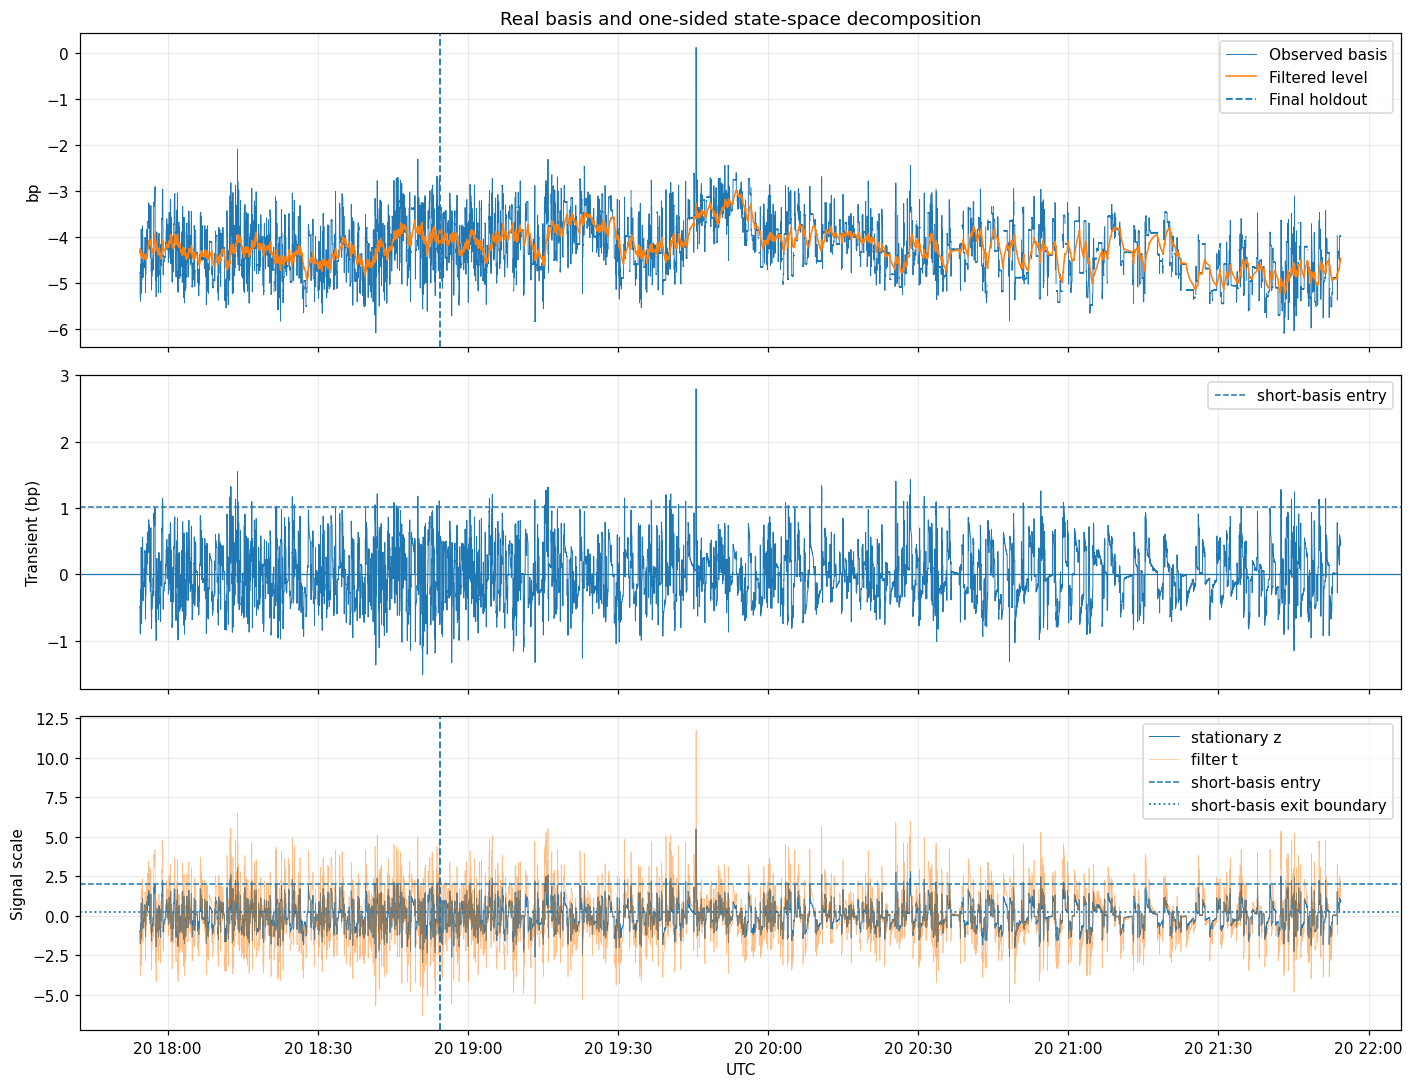

In [8]:
view = panel.loc[
    split.holdout_start - pd.Timedelta(hours=1):
    split.holdout_start + pd.Timedelta(hours=3)
]
transient_sd_bp = fit.params.transient_sd * 1e4

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
axes[0].plot(view.index, view["basis_bp"], lw=0.6, label="Observed basis")
axes[0].plot(view.index, view["level_bp"], lw=1.0, label="Filtered level")
axes[0].axvline(split.holdout_start, ls="--", lw=1.2, label="Final holdout")
axes[0].set_ylabel("bp")
axes[0].set_title("Real basis and one-sided state-space decomposition")
axes[0].legend(loc="upper right")

axes[1].plot(view.index, view["transient_bp"], lw=0.65)
axes[1].axhline(
    ENTRY_Z * transient_sd_bp,
    ls="--",
    lw=1,
    label="short-basis entry",
)
if ALLOW_SHORT_SPOT:
    axes[1].axhline(
        -ENTRY_Z * transient_sd_bp,
        ls="--",
        lw=1,
        label="long-basis entry",
    )
axes[1].axhline(0, lw=0.8)
axes[1].set_ylabel("Transient (bp)")
axes[1].legend(loc="upper right")

axes[2].plot(view.index, view["signal_state_space_z"], lw=0.65, label="stationary z")
axes[2].plot(view.index, view["signal_filter_t"], lw=0.45, alpha=0.5, label="filter t")
axes[2].axhline(ENTRY_Z, ls="--", lw=1, label="short-basis entry")
axes[2].axhline(EXIT_Z, ls=":", lw=1.2, label="short-basis exit boundary")
if ALLOW_SHORT_SPOT:
    axes[2].axhline(-ENTRY_Z, ls="--", lw=1, label="long-basis entry")
    axes[2].axhline(-EXIT_Z, ls=":", lw=1.2, label="long-basis exit boundary")
axes[2].axvline(split.holdout_start, ls="--", lw=1.2)
axes[2].set_ylabel("Signal scale")
axes[2].set_xlabel("UTC")
axes[2].legend(loc="upper right")
plt.tight_layout()
plt.show()

## 9. Timestamp-correct final-holdout proxy backtest

The primary configuration is evaluated once on the final holdout.

- Decision and fill timestamps are distinct.
- A fill cannot occur on the decision bar.
- Stale pending actions are cancelled across excessive data gaps.
- Mean-reversion exit is directional: crossing through zero and overshooting the opposite side still exits.
- Closed trades and the end-of-sample state are reported separately. An unfinished position is never silently dropped from the result.
- The open-position mark is hypothetical and is not added to realised P&L.


In [9]:
backtest_config = ProxyBacktestConfig(
    entry_z=ENTRY_Z,
    exit_z=EXIT_Z,
    stop_z=STOP_Z,
    max_hold_seconds=MAX_HOLD_SECONDS,
    cooldown_seconds=COOLDOWN_SECONDS,
    round_trip_cost_bp=ROUND_TRIP_COST_BP,
    execution_delay_seconds=EXECUTION_DELAY_SECONDS,
    max_fill_delay_seconds=MAX_FILL_DELAY_SECONDS,
    allow_short_spot=ALLOW_SHORT_SPOT,
)

state_space_result = run_proxy_backtest_detailed(
    panel,
    start_time=split.holdout_start,
    end_time=split.holdout_end_exclusive,
    config=backtest_config,
    basis_col="basis_bp",
    signal_col="signal_state_space_z",
    tradable_col="valid",
)
trades = state_space_result.trades

print(f"Round-trip modelled cost: {ROUND_TRIP_COST_BP:.2f} bp")
print(f"Final-holdout clock observations: {split.holdout_positions.size:,}")
print(f"Completed diagnostic trades: {len(trades):,}")
display(trades.head(10))
display(state_space_result.final_state.to_frame())


Round-trip modelled cost: 8.40 bp
Final-holdout clock observations: 18,334
Completed diagnostic trades: 37


,entry_decision_time,entry_time,exit_decision_time,exit_time,side,entry_basis_bp,exit_basis_bp,entry_signal_z,exit_signal_z,entry_fill_delay_s,exit_fill_delay_s,holding_s,gross_pnl_bp,cost_bp,net_pnl_bp,entry_reason,exit_reason
0,2026-07-20 19:04:17+00:00,2026-07-20 19:04:18+00:00,2026-07-20 19:04:29+00:00,2026-07-20 19:04:30+00:00,short_basis,-2.991520,-4.189656,2.056762,0.201749,1.0,1.0,12.0,1.198135,8.4,-7.201865,positive_transient,mean_reversion
1,2026-07-20 19:04:51+00:00,2026-07-20 19:04:52+00:00,2026-07-20 19:04:59+00:00,2026-07-20 19:05:00+00:00,short_basis,-2.732362,-4.030783,2.340247,0.109942,1.0,1.0,8.0,1.298422,8.4,-7.101578,positive_transient,mean_reversion
2,2026-07-20 19:13:22+00:00,2026-07-20 19:13:23+00:00,2026-07-20 19:13:24+00:00,2026-07-20 19:13:25+00:00,short_basis,-5.835112,-5.852007,2.211009,-2.554919,1.0,1.0,2.0,0.016895,8.4,-8.383105,positive_transient,mean_reversion
3,2026-07-20 19:15:24+00:00,2026-07-20 19:15:25+00:00,2026-07-20 19:16:02+00:00,2026-07-20 19:16:03+00:00,short_basis,-3.484800,-4.372600,2.041434,-0.536380,1.0,1.0,38.0,0.887800,8.4,-7.512200,positive_transient,mean_reversion
4,2026-07-20 19:31:17+00:00,2026-07-20 19:31:18+00:00,2026-07-20 19:31:21+00:00,2026-07-20 19:31:22+00:00,short_basis,-3.138803,-3.987647,2.178975,-0.030267,1.0,1.0,4.0,0.848844,8.4,-7.551156,positive_transient,mean_reversion
5,2026-07-20 19:36:39+00:00,2026-07-20 19:36:40+00:00,2026-07-20 19:36:44+00:00,2026-07-20 19:36:45+00:00,short_basis,-3.735384,-4.254918,2.197140,0.141069,1.0,1.0,5.0,0.519533,8.4,-7.880467,positive_transient,mean_reversion
6,2026-07-20 19:39:35+00:00,2026-07-20 19:39:36+00:00,2026-07-20 19:39:37+00:00,2026-07-20 19:39:38+00:00,short_basis,-4.063366,-3.948511,2.359466,-0.348699,1.0,1.0,2.0,-0.114855,8.4,-8.514855,positive_transient,mean_reversion
7,2026-07-20 19:40:18+00:00,2026-07-20 19:40:19+00:00,2026-07-20 19:40:24+00:00,2026-07-20 19:40:25+00:00,short_basis,-3.691011,-3.624401,2.185656,-0.339294,1.0,1.0,6.0,-0.066609,8.4,-8.466609,positive_transient,mean_reversion
8,2026-07-20 19:40:32+00:00,2026-07-20 19:40:33+00:00,2026-07-20 19:40:46+00:00,2026-07-20 19:40:47+00:00,short_basis,-4.015338,-4.001153,2.384308,0.249823,1.0,1.0,14.0,-0.014185,8.4,-8.414185,positive_transient,mean_reversion
9,2026-07-20 19:42:05+00:00,2026-07-20 19:42:06+00:00,2026-07-20 19:42:17+00:00,2026-07-20 19:42:18+00:00,short_basis,-2.899572,-4.353694,2.076040,-0.460078,1.0,1.0,12.0,1.454122,8.4,-6.945878,positive_transient,mean_reversion


,value
interval_start,2026-07-20 18:54:27+00:00
interval_end_exclusive,2026-07-21 00:00:01+00:00
last_clock_time,2026-07-21 00:00:00+00:00
last_tradable_time,2026-07-21 00:00:00+00:00
position,0
side,None
entry_decision_time,None
entry_time,None
entry_basis_bp,None
entry_signal_z,None


## 10. Realised proxy economics

Performance statistics below use completed trades only. The final-state table above must be read alongside them whenever an open position or pending instruction remains at the interval boundary.


model,state_space
trades,37
open_position,False
pending_action,None
open_mtm_net_if_liquidated_bp,None
cancelled_stale_actions,0
gross_total_bp,35.929632
net_total_bp,-274.870368
avg_gross_bp,0.971071
avg_net_bp,-7.428929
gross_win_rate,0.891892


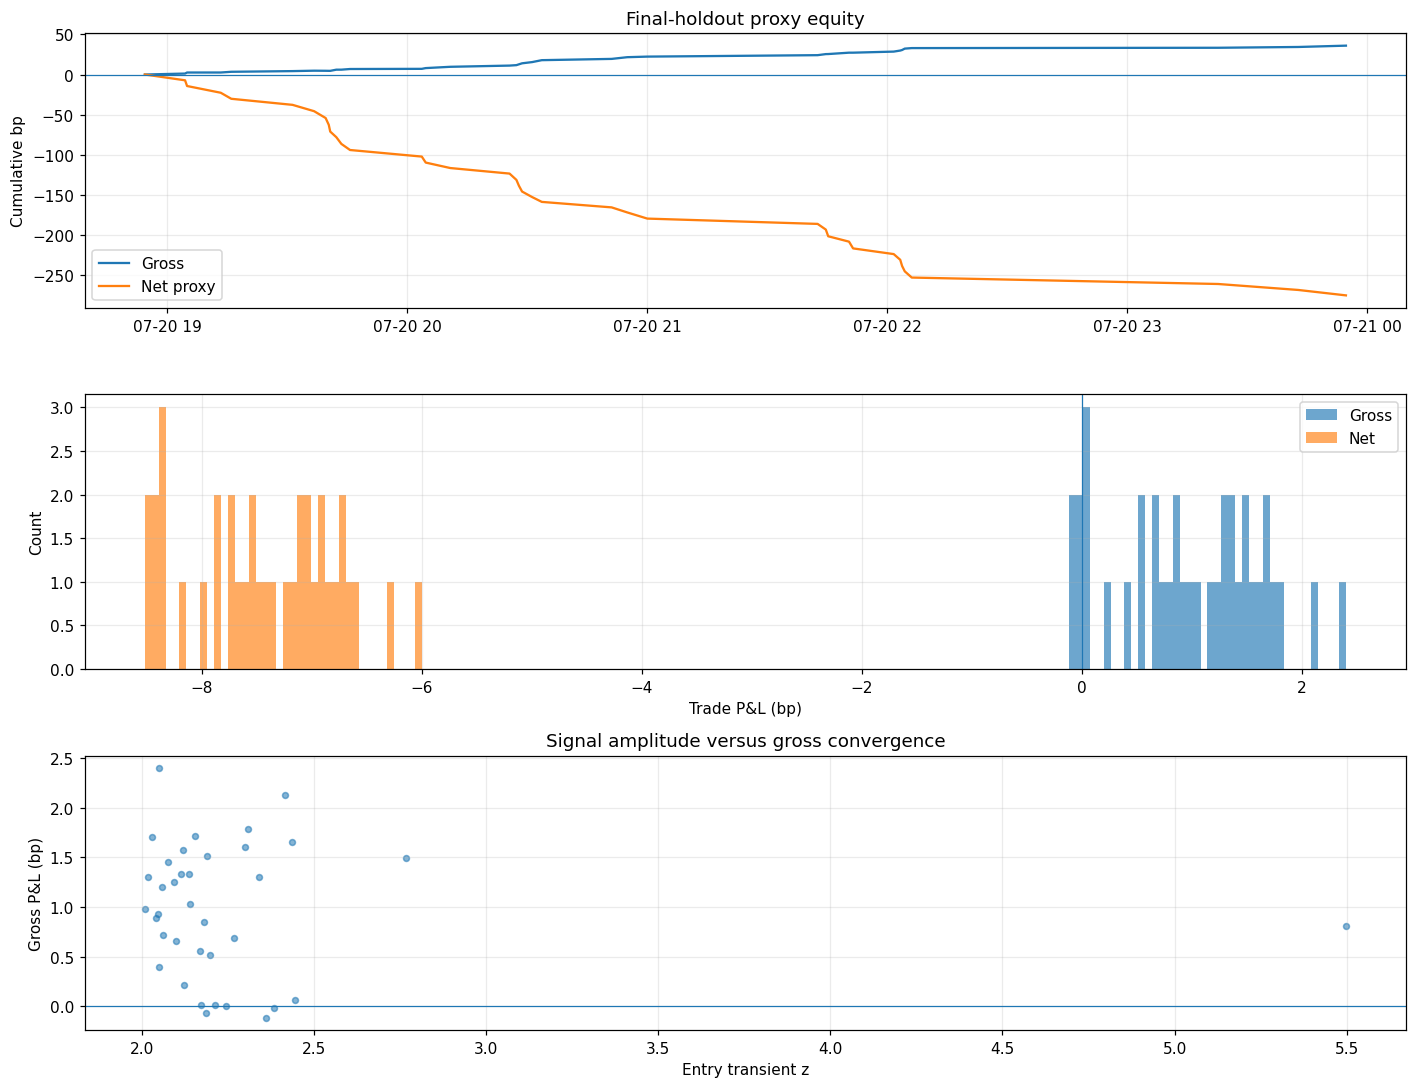

In [10]:
performance_row = summarize_proxy_result


state_space_performance = pd.DataFrame([
    performance_row(state_space_result, model="state_space")
]).set_index("model")
display(state_space_performance.T)

if not trades.empty:
    plot_trades = trades.copy()
    plot_trades["gross_equity_bp"] = plot_trades["gross_pnl_bp"].cumsum()
    plot_trades["net_equity_bp"] = plot_trades["net_pnl_bp"].cumsum()

    fig, axes = plt.subplots(3, 1, figsize=(13, 10))
    equity_times = pd.Index([split.holdout_start]).append(
        pd.DatetimeIndex(plot_trades["exit_time"])
    )
    axes[0].plot(equity_times, np.r_[0.0, plot_trades["gross_equity_bp"]], label="Gross")
    axes[0].plot(equity_times, np.r_[0.0, plot_trades["net_equity_bp"]], label="Net proxy")
    axes[0].axhline(0, lw=0.8)
    axes[0].set_ylabel("Cumulative bp")
    axes[0].set_title("Final-holdout proxy equity")
    axes[0].legend()

    axes[1].hist(plot_trades["gross_pnl_bp"], bins=40, alpha=0.65, label="Gross")
    axes[1].hist(plot_trades["net_pnl_bp"], bins=40, alpha=0.65, label="Net")
    axes[1].axvline(0, lw=0.8)
    axes[1].set_xlabel("Trade P&L (bp)")
    axes[1].set_ylabel("Count")
    axes[1].legend()

    axes[2].scatter(
        plot_trades["entry_signal_z"],
        plot_trades["gross_pnl_bp"],
        s=15,
        alpha=0.55,
    )
    axes[2].axhline(0, lw=0.8)
    axes[2].set_xlabel("Entry transient z")
    axes[2].set_ylabel("Gross P&L (bp)")
    axes[2].set_title("Signal amplitude versus gross convergence")
    plt.tight_layout()
    plt.show()


## 11. Final-holdout baseline comparison

All available models use the same predeclared threshold, tradability mask, fill delay, holding rules and costs. This isolates the incremental value of the state-space signal from execution-rule differences.

The rolling-z baseline is causal. The AR(1)/OU baseline is fitted only on training data. An explicit no-trade row anchors interpretation at zero activity and zero P&L. No baseline is selected or tuned using final-holdout performance.


In [11]:
model_signals = {
    "state_space": "signal_state_space_z",
    "causal_rolling_z": "signal_rolling_z",
}
if ar1_params is not None:
    model_signals["training_ar1_ou"] = "signal_ar1_ou_z"

holdout_results: dict[str, ProxyBacktestResult] = {}
for model_name, signal_column in model_signals.items():
    holdout_results[model_name] = run_proxy_backtest_detailed(
        panel,
        start_time=split.holdout_start,
        end_time=split.holdout_end_exclusive,
        config=backtest_config,
        basis_col="basis_bp",
        signal_col=signal_column,
        tradable_col="valid",
    )

comparison_rows = [
    performance_row(result, model=model_name)
    for model_name, result in holdout_results.items()
]
comparison_rows.append({
    "model": "no_trade",
    "trades": 0,
    "open_position": False,
    "pending_action": None,
    "open_mtm_net_if_liquidated_bp": None,
    "cancelled_stale_actions": 0,
    "gross_total_bp": 0.0,
    "net_total_bp": 0.0,
    "avg_gross_bp": np.nan,
    "avg_net_bp": np.nan,
    "gross_win_rate": np.nan,
    "net_win_rate": np.nan,
    "median_holding_s": np.nan,
    "max_drawdown_bp": 0.0,
})
comparison = pd.DataFrame(comparison_rows).set_index("model")
display(comparison.round(4))


,trades,open_position,pending_action,open_mtm_net_if_liquidated_bp,cancelled_stale_actions,gross_total_bp,net_total_bp,avg_gross_bp,avg_net_bp,gross_win_rate,net_win_rate,median_holding_s,max_drawdown_bp
model,,,,,,,,,,,,,
state_space,37,False,None,None,0,35.9296,-274.8704,0.9711,-7.4289,0.8919,0.0,8.0,-274.8704
causal_rolling_z,107,False,None,None,0,88.0095,-810.7905,0.8225,-7.5775,0.8972,0.0,12.0,-810.7905
training_ar1_ou,22,False,None,None,0,19.3225,-165.4775,0.8783,-7.5217,0.9091,0.0,24.5,-165.4775
no_trade,0,False,None,None,0,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,0.0000


## 12. Exploratory threshold sensitivity with FDR control

This sweep runs **only in the threshold-development interval**. It does not inspect the final holdout and it does not replace the predeclared `ENTRY_Z=2.0` result.

Only the entry threshold changes; `STOP_Z` and every execution rule remain fixed. The grid stops below `STOP_Z`, avoiding a confounded joint entry/stop sweep. For thresholds with enough completed episodes, a centred-null circular block-bootstrap tests whether mean gross convergence is positive. Benjamini–Hochberg adjusted values are reported across the exploratory family. These are dependent-data diagnostics, not a licence to promote the best-looking threshold.

,entry_z,trades,gross_total_bp,net_total_bp,avg_gross_bp,avg_net_bp,gross_mean_p,open_at_end,gross_mean_fdr_q
0,0.75,233,162.45838,-1794.74162,0.69725,-7.70275,0.0005,True,0.0005
1,1.00,189,138.29764,-1449.30236,0.73173,-7.66827,0.0005,True,0.0005
2,1.25,138,115.43620,-1043.76380,0.83649,-7.56351,0.0005,True,0.0005
3,1.50,100,88.25918,-751.74082,0.88259,-7.51741,0.0005,False,0.0005
4,1.75,60,61.21755,-442.78245,1.02029,-7.37971,0.0005,False,0.0005
5,2.00,30,33.94935,-218.05065,1.13164,-7.26836,0.0005,False,0.0005
6,2.25,14,12.78449,-104.81551,0.91318,-7.48682,0.0005,False,0.0005
7,2.50,6,3.99585,-46.40415,0.66598,-7.73402,NaN,False,NaN
8,2.75,3,0.29193,-24.90807,0.09731,-8.30269,NaN,False,NaN
9,3.00,2,-1.05722,-17.85722,-0.52861,-8.92861,NaN,False,NaN


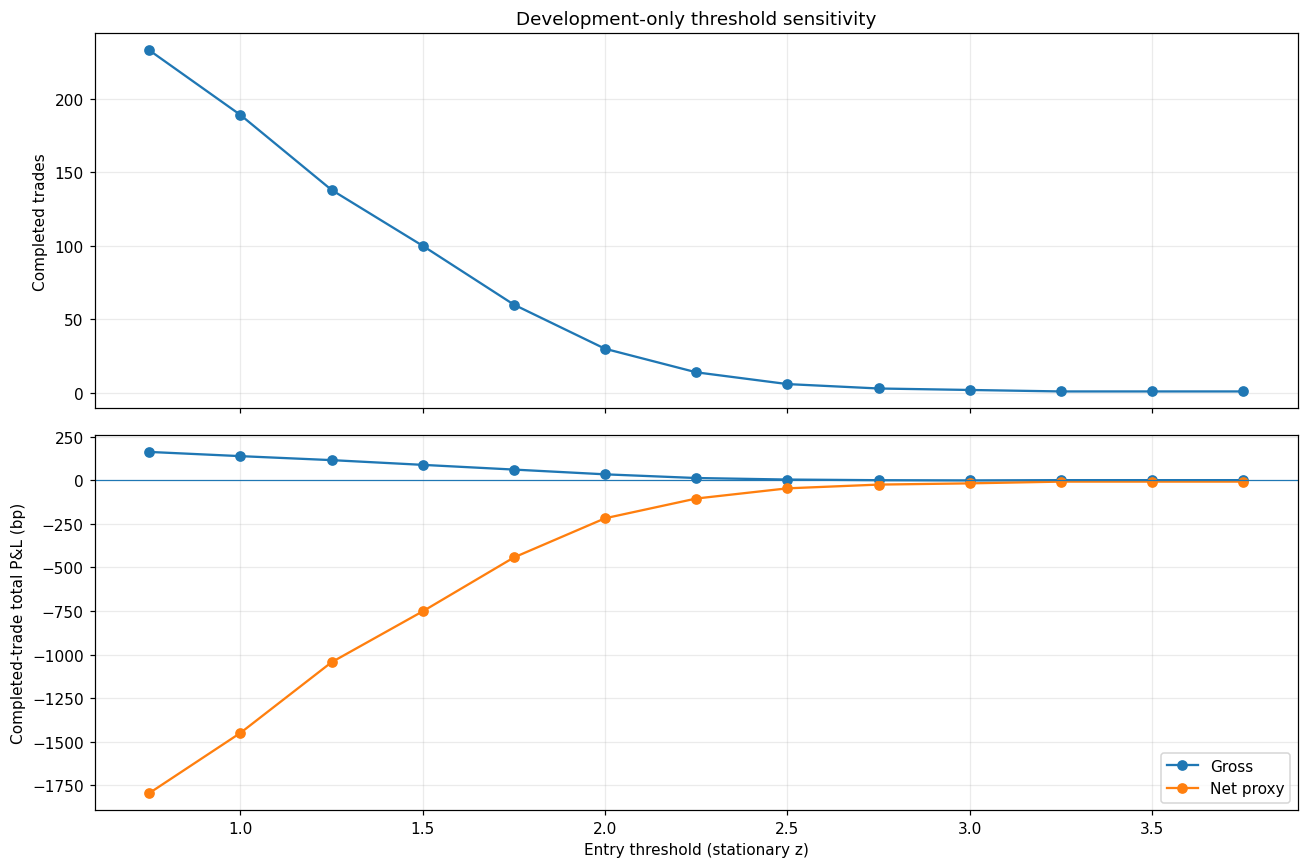

In [12]:
sweep_rows: list[dict[str, object]] = []
for threshold in THRESHOLD_GRID:
    candidate_config = ProxyBacktestConfig(
        entry_z=float(threshold),
        exit_z=EXIT_Z,
        stop_z=STOP_Z,
        max_hold_seconds=MAX_HOLD_SECONDS,
        cooldown_seconds=COOLDOWN_SECONDS,
        round_trip_cost_bp=ROUND_TRIP_COST_BP,
        execution_delay_seconds=EXECUTION_DELAY_SECONDS,
        max_fill_delay_seconds=MAX_FILL_DELAY_SECONDS,
        allow_short_spot=ALLOW_SHORT_SPOT,
    )
    candidate = run_proxy_backtest_detailed(
        panel,
        start_time=split.development_start,
        end_time=split.development_end_exclusive,
        config=candidate_config,
        basis_col="basis_bp",
        signal_col="signal_state_space_z",
        tradable_col="valid",
    )
    closed = candidate.trades
    p_value = np.nan
    if len(closed) >= 10:
        block_length = max(2, round(len(closed) ** (1 / 3)))
        test = circular_block_bootstrap_mean_test(
            closed["gross_pnl_bp"].to_numpy(),
            block_length=block_length,
            n_boot=BOOTSTRAP_REPLICATIONS,
            alternative="greater",
            seed=17,
        )
        p_value = float(test["p_value"])

    sweep_rows.append({
        "entry_z": float(threshold),
        "trades": len(closed),
        "gross_total_bp": 0.0 if closed.empty else closed["gross_pnl_bp"].sum(),
        "net_total_bp": 0.0 if closed.empty else closed["net_pnl_bp"].sum(),
        "avg_gross_bp": np.nan if closed.empty else closed["gross_pnl_bp"].mean(),
        "avg_net_bp": np.nan if closed.empty else closed["net_pnl_bp"].mean(),
        "gross_mean_p": p_value,
        "open_at_end": candidate.final_state.has_open_position,
    })

sweep = pd.DataFrame(sweep_rows)
sweep["gross_mean_fdr_q"] = np.nan
finite_p = sweep["gross_mean_p"].notna()
if finite_p.any():
    sweep.loc[finite_p, "gross_mean_fdr_q"] = benjamini_hochberg(
        sweep.loc[finite_p, "gross_mean_p"].to_numpy()
    )
display(sweep.round(5))

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(sweep["entry_z"], sweep["trades"], marker="o")
axes[0].set_ylabel("Completed trades")
axes[0].set_title("Development-only threshold sensitivity")
axes[1].plot(sweep["entry_z"], sweep["gross_total_bp"], marker="o", label="Gross")
axes[1].plot(sweep["entry_z"], sweep["net_total_bp"], marker="o", label="Net proxy")
axes[1].axhline(0, lw=0.8)
axes[1].set_xlabel("Entry threshold (stationary z)")
axes[1].set_ylabel("Completed-trade total P&L (bp)")
axes[1].legend()
plt.tight_layout()
plt.show()


## 13. Final economic and statistical decision

The decision table combines model preference, identifiability, final-holdout adequacy, signal scale, explicit cost scenarios and dependent-data uncertainty. Numeric promotion gates are predeclared in the configuration. A failure at any required gate keeps the result at `diagnostic_only` status.

The bootstrap is applied to completed final-holdout episodes only. An open terminal position remains separate in the final-state report. Baseline results are mandatory comparative context, but are not forced into a single automatic gate because trade count and per-episode quality are different estimands.

In [13]:
nominal_threshold_capture_bp = (ENTRY_Z - EXIT_Z) * transient_sd_bp
cost_to_signal = ROUND_TRIP_COST_BP / transient_sd_bp
cost_to_nominal_capture = ROUND_TRIP_COST_BP / nominal_threshold_capture_bp
bic_improvement = fit.delta_bic_vs_local_level
identification = fit.identifiability_summary()

bootstrap = None
bootstrap_test = None
if len(trades) >= MIN_FINAL_TRADES_FOR_INFERENCE:
    final_block_length = max(2, round(len(trades) ** (1 / 3)))
    bootstrap = circular_block_bootstrap_mean_ci(
        trades["gross_pnl_bp"].to_numpy(),
        block_length=final_block_length,
        n_boot=BOOTSTRAP_REPLICATIONS,
        confidence=0.95,
        seed=7,
    )
    bootstrap_test = circular_block_bootstrap_mean_test(
        trades["gross_pnl_bp"].to_numpy(),
        block_length=final_block_length,
        n_boot=BOOTSTRAP_REPLICATIONS,
        alternative="greater",
        seed=7,
    )

cost_stress = pd.DataFrame({
    "assumed_round_trip_cost_bp": COST_STRESS_BP,
})
cost_stress["completed_trade_net_total_bp"] = (
    0.0 if trades.empty else trades["gross_pnl_bp"].sum()
) - len(trades) * cost_stress["assumed_round_trip_cost_bp"]

promotion_gates = {
    "BIC gate": bool(
        bic_improvement is not None and bic_improvement >= MIN_DELTA_BIC
    ),
    "half-life identification gate": bool(
        identification["half_life_ratio"] <= MAX_IDENTIFICATION_RATIO
    ),
    "signal-scale identification gate": bool(
        identification["transient_sd_ratio"] <= MAX_IDENTIFICATION_RATIO
    ),
    "dynamic adequacy gate": bool(adequacy.dynamic_passed),
    "economic-scale gate": bool(cost_to_nominal_capture < 1.0),
    "completed-episode count gate": bool(
        len(trades) >= MIN_FINAL_TRADES_FOR_INFERENCE
    ),
    "dependent-data gross-mean gate": bool(
        bootstrap is not None
        and bootstrap_test is not None
        and bootstrap["lower"] > 0.0
        and bootstrap_test["p_value"] < 0.05
    ),
}
research_status = (
    "execution_research_candidate"
    if all(promotion_gates.values())
    else "diagnostic_only"
)

state_avg_gross = comparison.loc["state_space", "avg_gross_bp"]
rolling_avg_gross = comparison.loc["causal_rolling_z", "avg_gross_bp"]

decision: dict[str, object] = {
    "research status": research_status,
    "scope": "single settled UTC day by design",
    "real data": True,
    "training clock observations": split.train_positions.size,
    "development clock observations": split.development_positions.size,
    "purge clock observations": split.purge_positions.size,
    "final-holdout clock observations": split.holdout_positions.size,
    "training valid observations": int(np.isfinite(train_y).sum()),
    "half-life (s)": fit.half_life,
    "transient stationary sd (bp)": transient_sd_bp,
    "assumed round-trip cost (bp)": ROUND_TRIP_COST_BP,
    "nominal entry-to-exit transient capture (bp)": nominal_threshold_capture_bp,
    "cost / transient sd": cost_to_signal,
    "cost / nominal threshold capture": cost_to_nominal_capture,
    "BIC improvement vs local-level null": bic_improvement,
    "near-optimal half-life ratio": identification["half_life_ratio"],
    "near-optimal signal-scale ratio": identification["transient_sd_ratio"],
    "final-holdout dynamic adequacy passed": adequacy.dynamic_passed,
    "final-holdout Gaussian innovations passed": adequacy.gaussian_passed,
    "completed final-holdout trades": len(trades),
    "open final position": state_space_result.final_state.has_open_position,
    "open MTM net if liquidated (bp)": (
        state_space_result.final_state.mark_to_market_net_bp_if_liquidated
    ),
    "gross completed-trade total (bp)": (
        0.0 if trades.empty else trades["gross_pnl_bp"].sum()
    ),
    "net completed-trade total (bp)": (
        0.0 if trades.empty else trades["net_pnl_bp"].sum()
    ),
    "state-space average gross (bp/trade)": state_avg_gross,
    "rolling-z average gross (bp/trade)": rolling_avg_gross,
}
if bootstrap is not None:
    decision.update({
        "gross mean bootstrap lower (bp/trade)": bootstrap["lower"],
        "gross mean bootstrap upper (bp/trade)": bootstrap["upper"],
        "bootstrap resample fraction(mean > 0)": bootstrap["probability_mean_positive"],
        "centred-null bootstrap p-value": bootstrap_test["p_value"],
    })
display(pd.Series(decision, name="value").to_frame())
display(pd.Series(promotion_gates, name="passed").to_frame())
display(cost_stress)

print("INTERPRETATION")
print(f"- Research status: {research_status}.")
for gate_name, passed in promotion_gates.items():
    print(f"- {gate_name}: {'PASS' if passed else 'FAIL'}")
if not adequacy.gaussian_passed:
    print("- Gaussian innovations are rejected; robust inference is required.")
print("- Baselines are comparative context, not an automatically optimised selector.")
print("- Closed-trade convergence and terminal open inventory are reported separately.")
print("- No executable-fill claim is made from aggTrades data.")

,value
research status,diagnostic_only
scope,single settled UTC day by design
real data,True
training clock observations,60000
development clock observations,8000
purge clock observations,66
final-holdout clock observations,18334
training valid observations,58984
half-life (s),3.424108
transient stationary sd (bp),0.508721


,passed
BIC gate,True
half-life identification gate,True
signal-scale identification gate,True
dynamic adequacy gate,False
economic-scale gate,False
completed-episode count gate,True
dependent-data gross-mean gate,True


,assumed_round_trip_cost_bp,completed_trade_net_total_bp
0,0.0,35.929632
1,8.4,-274.870368
2,20.0,-704.070368
3,40.0,-1444.070368


INTERPRETATION
- Research status: diagnostic_only.
- BIC gate: PASS
- half-life identification gate: PASS
- signal-scale identification gate: PASS
- dynamic adequacy gate: FAIL
- economic-scale gate: FAIL
- completed-episode count gate: PASS
- dependent-data gross-mean gate: PASS
- Gaussian innovations are rejected; robust inference is required.
- Baselines are comparative context, not an automatically optimised selector.
- Closed-trade convergence and terminal open inventory are reported separately.
- No executable-fill claim is made from aggTrades data.


## 14. Persist the fit and run manifest

The manifest records the exact UTC day, archive URLs and SHA-256 digests, parsed row counts, configuration, Python and package versions, Git commit/dirty state, partition boundaries, promotion gates and principal outputs. This makes a reproduced run auditable even when a remote archive or local environment later changes.

In [14]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
fit_path = OUTPUT_DIR / f"{SYMBOL}_{DATE}_state_space_fit.json"
manifest_path = OUTPUT_DIR / f"{SYMBOL}_{DATE}_research_manifest.json"
fit.save_json(fit_path)

manifest = write_research_manifest(
    manifest_path,
    study={
        "name": "BTC spot-perpetual single-day causal state-space research",
        "scope": "single-day by design; multi-day research is a separate project",
        "symbol": SYMBOL,
        "utc_date": DATE,
        "bar_seconds": BAR_SECONDS,
        "parser_version": PARSER_VERSION,
        **git_revision(Path.cwd()),
        "training_start": split.train_start,
        "training_end_exclusive": split.train_end_exclusive,
        "development_start": split.development_start,
        "development_end_exclusive": split.development_end_exclusive,
        "holdout_start": split.holdout_start,
        "holdout_end_exclusive": split.holdout_end_exclusive,
    },
    archives=[perp_archive, spot_archive],
    configuration={
        "max_stale_seconds": MAX_STALE_SECONDS,
        "entry_z": ENTRY_Z,
        "exit_z": EXIT_Z,
        "stop_z": STOP_Z,
        "max_hold_seconds": MAX_HOLD_SECONDS,
        "cooldown_seconds": COOLDOWN_SECONDS,
        "execution_delay_seconds": EXECUTION_DELAY_SECONDS,
        "max_fill_delay_seconds": MAX_FILL_DELAY_SECONDS,
        "assumed_fee_bp_per_fill": ASSUMED_FEE_BP_PER_FILL,
        "assumed_slippage_bp_per_fill": ASSUMED_SLIPPAGE_BP_PER_FILL,
        "round_trip_cost_bp": ROUND_TRIP_COST_BP,
        "minimum_delta_bic": MIN_DELTA_BIC,
        "maximum_identification_ratio": MAX_IDENTIFICATION_RATIO,
        "minimum_final_trades_for_inference": MIN_FINAL_TRADES_FOR_INFERENCE,
        "allow_short_spot": ALLOW_SHORT_SPOT,
        "rolling_window_seconds": ROLLING_WINDOW_SECONDS,
        "cost_stress_bp": COST_STRESS_BP,
    },
    outputs={
        "fit_json": str(fit_path),
        "completed_holdout_trades": len(trades),
        "terminal_state": state_space_result.final_state.to_frame()["value"].to_dict(),
        "dynamic_adequacy_passed": adequacy.dynamic_passed,
        "gaussian_adequacy_passed": adequacy.gaussian_passed,
        "delta_bic_vs_local_level": bic_improvement,
        "research_status": research_status,
        "promotion_gates": promotion_gates,
    },
    package_versions={
        "python": platform.python_version(),
        **installed_versions([
            "numpy", "scipy", "numba", "pandas", "matplotlib", "ipython"
        ]),
    },
)
print(f"Wrote fit: {fit_path}")
print(f"Wrote manifest: {manifest}")


Wrote fit: artifacts/BTCUSDT_2026-07-20_state_space_fit.json
Wrote manifest: artifacts/BTCUSDT_2026-07-20_research_manifest.json


## 15. Reusable signal semantics

### Historical fit

```python
from state_space import fit_state_space, filter_state_space

fit = fit_state_space(training_basis_log, dt=1.0)
result = filter_state_space(all_basis_log, fit)

signal_stationary_z = result.transient_stationary_z(fit.params)
signal_filter_t = result.transient_filter_t
```

### Online update

```python
from state_space import OnlineBasisFilter

online = OnlineBasisFilter.from_history(fit.params, training_basis_log)
state = online.update(new_basis_log)
print(state["transient_stationary_z"], state["transient_filter_t"])
```

The state-space module estimates and filters the signal. Execution, inventory, funding, borrow, order acknowledgement, partial fills and reconciliation remain separate systems.


## 16. Boundary and handoff

This notebook ends at a trade-price proxy and an explicit economic gate.

A separate execution-research project would require synchronized bid/ask or depth data, crossing-versus-maker assumptions, two-leg latency, partial fills, cancellation state, adverse-selection measurement and the account's own order/execution telemetry.

Likewise, a separate multi-day project would address cross-date refits, regime stability and prospective evaluation. Neither extension should be silently folded into this deliberately single-day repository.
